In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
#read in inputs

code_file = Path().resolve()
input_file = code_file / 'HydrologyScenarios.xlsx'
elev_cap_file = code_file / 'Lake_Powell_2018_ElevAreaCap_calc.csv'

excluded_sheets = [
    "ReadMe", "AvailableHydrologyScenarios", "ScenarioListForAnalysis",
    "AvailableMetrics", "MetricsForAnalysis", "Heatmap", "Hist"
]

sheet_names = pd.ExcelFile(input_file).sheet_names

all_series = []

for ensemble_name in sheet_names:
    if ensemble_name in excluded_sheets:
        continue

    df = pd.read_excel(input_file, sheet_name=ensemble_name)
    df = df.apply(pd.to_numeric, errors='coerce')

    years = df.iloc[:, 0]          # first column = year
    traces = df.columns[1:]        # remaining columns = traces

    for trace in traces:
        series = df[trace].dropna().reset_index(drop=True)

        for i, value in enumerate(series):
            all_series.append({
                "Ensemble": ensemble_name,
                "Trace": trace,
                "YearIndex": i,
                "Year": years.iloc[i],
                "Inflow_MAF": value
            })

inflow_df = pd.DataFrame(all_series)


In [3]:
ANNUAL_RELEASE_MAF = 8.3  # change this as needed

inflow_df["Release_MAF"] = ANNUAL_RELEASE_MAF



In [4]:
INITIAL_STORAGE_MAF = 5.49  # set your starting Powell storage 
#3490 ft = 5.49427336 MAF
#3500 ft = 5.96185804 MAF
#3525 ft = 7.31209764 MAF

def compute_storage(group):
    group = group.sort_values("YearIndex").copy()
    storage = [INITIAL_STORAGE_MAF]

    for i in range(len(group)):
        prev_S = storage[-1]
        Qin = group.iloc[i]["Inflow_MAF"]
        Qrel = group.iloc[i]["Release_MAF"]
        storage.append(prev_S + Qin - Qrel)

    group["Storage_MAF"] = storage[1:]
    return group

storage_df = (
    inflow_df
    .groupby(["Ensemble", "Trace"], group_keys=False)
    .apply(compute_storage)
)


C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\520594981.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_storage)


In [5]:
elev_cap = pd.read_csv(elev_cap_file)

# Columns are:
# 'Elevation_ft_NAVD88', 'Elevation_ft_NGVD29', 'Area_acres', 'Capacity_acrefeet'
elev_cap["Storage_MAF"] = elev_cap["Capacity_acrefeet"] / 1_000_000.0
elev_cap = elev_cap.sort_values("Storage_MAF")

def storage_to_elevation(storage_maf):
    return np.interp(
        storage_maf,
        elev_cap["Storage_MAF"].values,
        elev_cap["Elevation_ft_NAVD88"].values
    )

storage_df["Elevation_ft"] = storage_to_elevation(storage_df["Storage_MAF"])


In [6]:
trace_mins = (
    storage_df
    .groupby(["Ensemble", "Trace"])["Storage_MAF"]
    .min()
    .reset_index(name="MinStorage_MAF")
)

threshold = 5.49427336

# Minimum storage per trace
trace_mins = (
    storage_df
    .groupby(["Ensemble", "Trace"])["Storage_MAF"]
    .min()
    .reset_index(name="MinStorage_MAF")
)

# Flag traces below threshold
trace_mins["BelowThreshold"] = trace_mins["MinStorage_MAF"] < threshold

# Ensemble-level True/False summary
ensemble_flags = (
    trace_mins
    .groupby("Ensemble")["BelowThreshold"]
    .any()
    .reset_index(name="AnyTraceBelowThreshold")
)

print(ensemble_flags)


              Ensemble  AnyTraceBelowThreshold
0                  AR1                    True
1                CMIP3                   False
2           CMIP5_BCSD                    True
3           CMIP5_LOCA                    True
4      Drought_Mid20th                    True
5   Drought_Millennium                    True
6        Drought_Paleo                    True
7             ISM_Full                    True
8   ISM_PluvialRemoved                    True
9       ISM_StressTest                    True
10         ISM_TRM17SK                    True
11    Mill_5YrBlockRes                    True
12       NPC_1906_2020                    True
13       NPC_1988_2020                    True
14       NPC_2000_2020                    True
15           RCP45_030                    True
16           RCP45_065                    True
17           RCP45_100                    True
18           RCP85_030                    True
19           RCP85_065                    True
20           

In [7]:
ANNUAL_RELEASE_MAF = 6.0  # change this as needed

inflow_df["Release_MAF"] = ANNUAL_RELEASE_MAF

# Starting storage scenarios (MAF)
start_values = {
    "3490 ft\n(5.49 MAF)": 5.49427336,
    "3500 ft\n(5.96 MAF)": 5.96185804,
    "3525 ft\n(7.31 MAF)": 7.31209764
}

failure_threshold = 5.49427336  # 3490 ft

results = []

for label, start_storage in start_values.items():

    # --- 1. Recompute storage for this starting condition ---
    def compute_storage(group):
        group = group.sort_values("YearIndex").copy()
        storage = [start_storage]

        for i in range(len(group)):
            prev_S = storage[-1]
            Qin = group.iloc[i]["Inflow_MAF"]
            Qrel = group.iloc[i]["Release_MAF"]
            storage.append(prev_S + Qin - Qrel)

        group["Storage_MAF"] = storage[1:]
        return group

    storage_df_scenario = (
        inflow_df
        .groupby(["Ensemble", "Trace"], group_keys=False)
        .apply(compute_storage)
    )

    # --- 2. Compute minimum storage per trace ---
    trace_mins = (
        storage_df_scenario
        .groupby(["Ensemble", "Trace"])["Storage_MAF"]
        .min()
        .reset_index(name="MinStorage_MAF")
    )

    # --- 3. Count ensembles with ANY trace below 5.49 MAF ---
    failing_ensembles = (
        trace_mins
        .groupby("Ensemble")["MinStorage_MAF"]
        .apply(lambda x: (x < failure_threshold).any())
        .sum()
    )

    results.append({
        "StartingStorage": label,
        "EnsemblesFailingBelow3490": failing_ensembles
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)


C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\3342138328.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_storage)
C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\3342138328.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_storage)
C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\3342138328.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grou

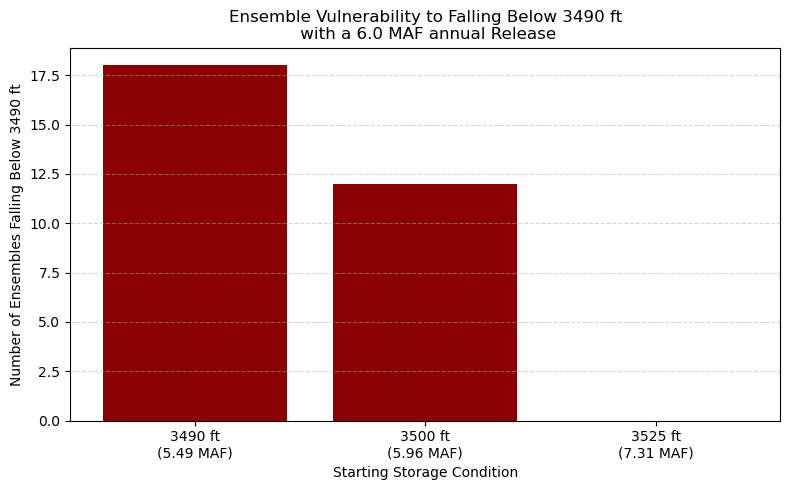

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["StartingStorage"],
        results_df["EnsemblesFailingBelow3490"],
        color="darkred")

plt.ylabel("Number of Ensembles Falling Below 3490 ft")
plt.xlabel("Starting Storage Condition")
plt.title("Ensemble Vulnerability to Falling Below 3490 ft\n with a 6.0 MAF annual Release")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\3952616121.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_storage)
C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\3952616121.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_storage)
C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\3952616121.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grou

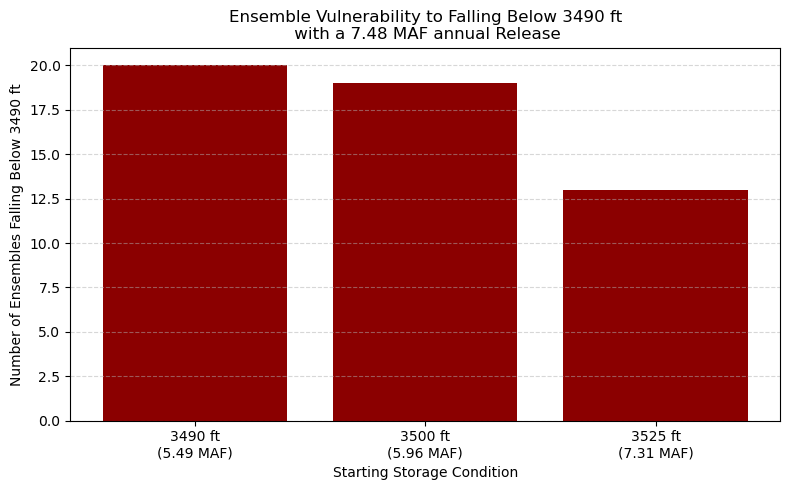

In [9]:
ANNUAL_RELEASE_MAF = 7.48  # change this as needed

inflow_df["Release_MAF"] = ANNUAL_RELEASE_MAF

# Starting storage scenarios (MAF)
start_values = {
    "3490 ft\n(5.49 MAF)": 5.49427336,
    "3500 ft\n(5.96 MAF)": 5.96185804,
    "3525 ft\n(7.31 MAF)": 7.31209764
}

failure_threshold = 5.49427336  # 3490 ft

results = []

for label, start_storage in start_values.items():

    # --- 1. Recompute storage for this starting condition ---
    def compute_storage(group):
        group = group.sort_values("YearIndex").copy()
        storage = [start_storage]

        for i in range(len(group)):
            prev_S = storage[-1]
            Qin = group.iloc[i]["Inflow_MAF"]
            Qrel = group.iloc[i]["Release_MAF"]
            storage.append(prev_S + Qin - Qrel)

        group["Storage_MAF"] = storage[1:]
        return group

    storage_df_scenario = (
        inflow_df
        .groupby(["Ensemble", "Trace"], group_keys=False)
        .apply(compute_storage)
    )

    # --- 2. Compute minimum storage per trace ---
    trace_mins = (
        storage_df_scenario
        .groupby(["Ensemble", "Trace"])["Storage_MAF"]
        .min()
        .reset_index(name="MinStorage_MAF")
    )

    # --- 3. Count ensembles with ANY trace below 5.49 MAF ---
    failing_ensembles = (
        trace_mins
        .groupby("Ensemble")["MinStorage_MAF"]
        .apply(lambda x: (x < failure_threshold).any())
        .sum()
    )

    results.append({
        "StartingStorage": label,
        "EnsemblesFailingBelow3490": failing_ensembles
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
plt.bar(results_df["StartingStorage"],
        results_df["EnsemblesFailingBelow3490"],
        color="darkred")

plt.ylabel("Number of Ensembles Falling Below 3490 ft")
plt.xlabel("Starting Storage Condition")
plt.title("Ensemble Vulnerability to Falling Below 3490 ft\n with a 7.48 MAF annual Release")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\836909398.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_storage)
C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\836909398.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_storage)
C:\Users\Fager\AppData\Local\Temp\ipykernel_101456\836909398.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the groupin

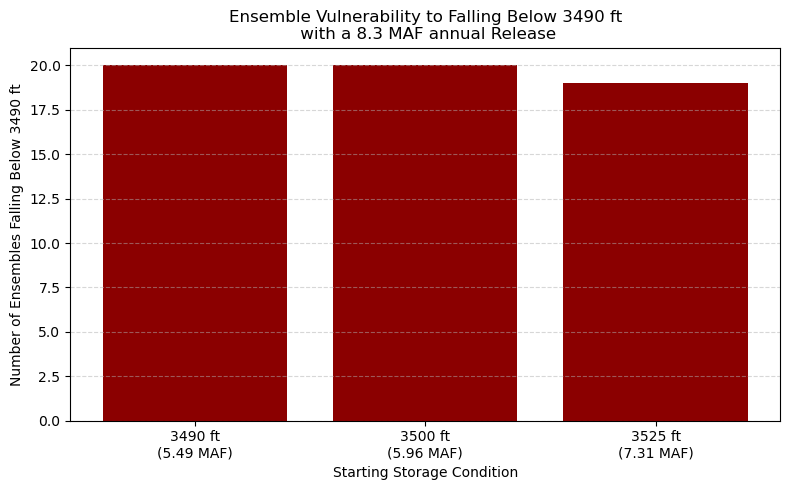

In [10]:
ANNUAL_RELEASE_MAF = 8.3  # change this as needed

inflow_df["Release_MAF"] = ANNUAL_RELEASE_MAF

# Starting storage scenarios (MAF)
start_values = {
    "3490 ft\n(5.49 MAF)": 5.49427336,
    "3500 ft\n(5.96 MAF)": 5.96185804,
    "3525 ft\n(7.31 MAF)": 7.31209764
}

failure_threshold = 5.49427336  # 3490 ft

results = []

for label, start_storage in start_values.items():

    # --- 1. Recompute storage for this starting condition ---
    def compute_storage(group):
        group = group.sort_values("YearIndex").copy()
        storage = [start_storage]

        for i in range(len(group)):
            prev_S = storage[-1]
            Qin = group.iloc[i]["Inflow_MAF"]
            Qrel = group.iloc[i]["Release_MAF"]
            storage.append(prev_S + Qin - Qrel)

        group["Storage_MAF"] = storage[1:]
        return group

    storage_df_scenario = (
        inflow_df
        .groupby(["Ensemble", "Trace"], group_keys=False)
        .apply(compute_storage)
    )

    # --- 2. Compute minimum storage per trace ---
    trace_mins = (
        storage_df_scenario
        .groupby(["Ensemble", "Trace"])["Storage_MAF"]
        .min()
        .reset_index(name="MinStorage_MAF")
    )

    # --- 3. Count ensembles with ANY trace below 5.49 MAF ---
    failing_ensembles = (
        trace_mins
        .groupby("Ensemble")["MinStorage_MAF"]
        .apply(lambda x: (x < failure_threshold).any())
        .sum()
    )

    results.append({
        "StartingStorage": label,
        "EnsemblesFailingBelow3490": failing_ensembles
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
plt.bar(results_df["StartingStorage"],
        results_df["EnsemblesFailingBelow3490"],
        color="darkred")

plt.ylabel("Number of Ensembles Falling Below 3490 ft")
plt.xlabel("Starting Storage Condition")
plt.title("Ensemble Vulnerability to Falling Below 3490 ft\n with a 8.3 MAF annual Release")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



In [11]:
# Sort to ensure correct ordering
df = inflow_df.sort_values(["Ensemble", "Trace", "YearIndex"]).copy()

# Compute next year's flow
df["NextFlow_MAF"] = (
    df.groupby(["Ensemble", "Trace"])["Inflow_MAF"].shift(-1)
)

# Compute next year's index
df["NextYearIndex"] = (
    df.groupby(["Ensemble", "Trace"])["YearIndex"].shift(-1)
)

# Compute year-to-year difference
df["Difference_MAF"] = df["NextFlow_MAF"] - df["Inflow_MAF"]

# Keep only valid pairs (i.e., where next year exists)
pair_df = df.dropna(subset=["NextFlow_MAF"]).copy()

# Select final columns
pair_df = pair_df[[
    "Ensemble",
    "Trace",
    "YearIndex",
    "NextYearIndex",
    "Inflow_MAF",
    "NextFlow_MAF",
    "Difference_MAF"
]]

pair_df.to_csv("AllHydrology_YearToYearPairs.csv", index=False)



In [12]:
lowflow_pairs = pair_df[pair_df["Inflow_MAF"] < 12.3].copy()
lowflow_drops = lowflow_pairs[lowflow_pairs["Difference_MAF"] < 0].copy()


In [13]:
START_STORAGE = 5.49
RELEASE = 8.3
THRESHOLD = 5.49

# pair_df must contain: Ensemble, Trace, YearIndex, NextYearIndex, Inflow_MAF, NextFlow_MAF, Difference_MAF

# Compute storage using the NEXT YEAR's inflow (Inflow at t+1)
pair_df["Storage_UsingNextYear"] = START_STORAGE + pair_df["NextFlow_MAF"] - RELEASE

# Flag pairs that fall below threshold
pair_df["BelowThreshold"] = pair_df["Storage_UsingNextYear"] < THRESHOLD

# Ensemble-level flag: True means the ensemble never fails (stays above), False means at least one pair fails
ensemble_flags = (
    pair_df
    .groupby("Ensemble")["BelowThreshold"]
    .apply(lambda x: not x.any())
    .reset_index(name="StaysAbove_5_49_MAF")
)

# Print the ensemble table
print(ensemble_flags.to_string(index=False))


          Ensemble  StaysAbove_5_49_MAF
               AR1                False
             CMIP3                False
        CMIP5_BCSD                False
        CMIP5_LOCA                False
   Drought_Mid20th                False
Drought_Millennium                False
     Drought_Paleo                False
          ISM_Full                False
ISM_PluvialRemoved                False
    ISM_StressTest                False
       ISM_TRM17SK                False
  Mill_5YrBlockRes                False
     NPC_1906_2020                False
     NPC_1988_2020                False
     NPC_2000_2020                False
         RCP45_030                False
         RCP45_065                False
         RCP45_100                False
         RCP85_030                False
         RCP85_065                False
         RCP85_100                False
     TreeRingFlows                False


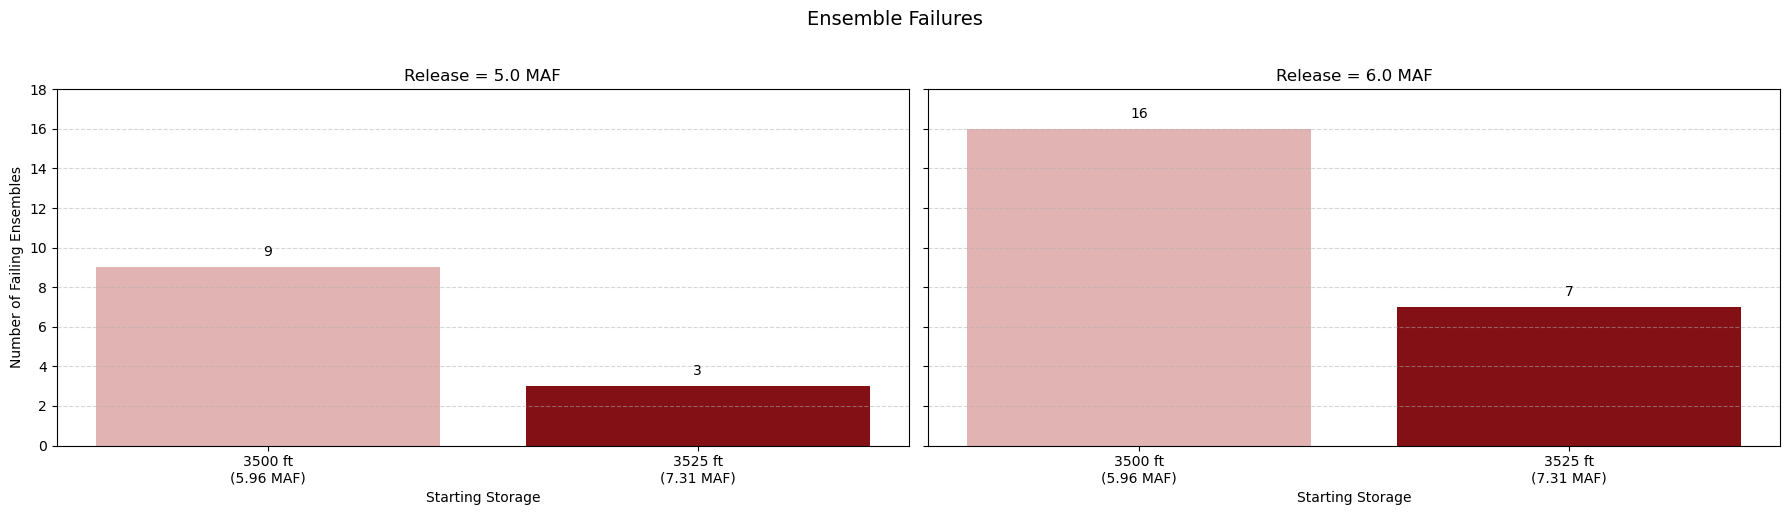

In [14]:


# --- Preconditions: ensure pair_df exists; if not, build from inflow_df ---
# pair_df should have: Ensemble, Trace, YearIndex, NextYearIndex, Inflow_MAF, NextFlow_MAF, Difference_MAF
if 'pair_df' not in globals():
    if 'inflow_df' not in globals():
        raise RuntimeError("Neither pair_df nor inflow_df is available in the environment.")
    df = inflow_df.sort_values(["Ensemble", "Trace", "YearIndex"]).copy()
    df["NextFlow_MAF"] = df.groupby(["Ensemble", "Trace"])["Inflow_MAF"].shift(-1)
    df["NextYearIndex"] = df.groupby(["Ensemble", "Trace"])["YearIndex"].shift(-1)
    df["Difference_MAF"] = df["NextFlow_MAF"] - df["Inflow_MAF"]
    pair_df = df.dropna(subset=["NextFlow_MAF"]).copy()
    pair_df = pair_df[[
        "Ensemble", "Trace", "YearIndex", "NextYearIndex",
        "Inflow_MAF", "NextFlow_MAF", "Difference_MAF"
    ]].reset_index(drop=True)
else:
    # ensure required columns exist
    required = {"Ensemble", "Trace", "YearIndex", "NextYearIndex", "Inflow_MAF", "NextFlow_MAF", "Difference_MAF"}
    missing = required - set(pair_df.columns)
    if missing:
        raise RuntimeError(f"pair_df is missing required columns: {missing}")
    pair_df = pair_df.dropna(subset=["NextFlow_MAF"]).copy()

# --- Scenarios ---
start_values = {
    #"3490 ft\n(5.49 MAF)": 5.49427336,
    "3500 ft\n(5.96 MAF)": 5.96185804,
    "3525 ft\n(7.31 MAF)": 7.31209764
}

releases = [5.0, 6.0]
THRESHOLD = 5.49

# Prepare results container
results = []

# Compute counts for each release and starting storage
for release in releases:
    counts = {}
    for label, start_storage in start_values.items():
        # Compute storage using NEXT YEAR's inflow (one-step test)
        storage_col = start_storage + pair_df["NextFlow_MAF"] - release
        below = storage_col < THRESHOLD

        # Attach to a temporary DataFrame to group by Ensemble
        tmp = pair_df[["Ensemble"]].copy()
        tmp["BelowThreshold"] = below.values

        # Ensemble fails if any pair is below threshold
        ensemble_fail_flags = tmp.groupby("Ensemble")["BelowThreshold"].any()
        failing_ensembles = int(ensemble_fail_flags.sum())

        counts[label] = failing_ensembles
        results.append({
            "Release": release,
            "StartingStorageLabel": label,
            "StartingStorage_MAF": start_storage,
            "FailingEnsembles": failing_ensembles
        })

# Convert results to DataFrame for printing
results_df = pd.DataFrame(results)

# --- Plotting: 3 subplots (1 row x 3 columns) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
plt.subplots_adjust(wspace=0.35)

# Determine consistent y-axis max
max_count = results_df["FailingEnsembles"].max()
ymax = int(np.ceil(max_count * 1.1)) if max_count > 0 else 1

for ax, release in zip(axes, releases):
    subset = results_df[results_df["Release"] == release].copy()
    # Keep the order of start_values
    labels = list(start_values.keys())
    counts = [int(subset[subset["StartingStorageLabel"] == lbl]["FailingEnsembles"].values[0]) for lbl in labels]

    colors = ["#e2b3b3",  "#821014"] # "#B22222",
    bars = ax.bar(labels, counts, color=[colors[i % 3] for i in range(len(counts))])

    ax.set_title(f"Release = {release} MAF")
    ax.set_xlabel("Starting Storage")
    ax.set_ylabel("Number of Failing Ensembles" if ax is axes[0] else "")
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Annotate bars with counts
    for bar, cnt in zip(bars, counts):
        height = bar.get_height()
        ax.annotate(f"{cnt}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 6), textcoords="offset points", ha="center", va="bottom", fontsize=10)

# Tight layout and show
plt.suptitle("Ensemble Failures", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print results table
#print(results_df.sort_values(["Release", "StartingStorage_MAF"]).to_string(index=False))
